# Regresión Logística
Predicción de mortalidad

## Importación de librerías y dataset

In [92]:
from notebook_utils import ensure_repo_root

# Establish the repository root as the working directory for this notebook
ensure_repo_root()

WindowsPath('C:/Github/NTR-Arogyaseva-analysis')

In [93]:
from src.utils.io import load_data, set_pandas_display_options
from src.utils.text import to_title_case

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import statsmodels.api as sm

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Establecer opciones de visualización para pandas
#set_pandas_display_options()

# Importar el dataset
df = load_data(stage="processed")

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479688 entries, 0 to 479687
Data columns (total 39 columns):
 #   Column                                   Non-Null Count   Dtype         
---  ------                                   --------------   -----         
 0   age                                      479688 non-null  int64         
 1   sex                                      479688 non-null  object        
 2   caste_name                               479688 non-null  object        
 3   category_code                            479688 non-null  object        
 4   category_name                            479688 non-null  object        
 5   surgery_code                             479688 non-null  object        
 6   surgery                                  479688 non-null  object        
 7   village                                  479688 non-null  object        
 8   mandal_name                              479688 non-null  object        
 9   district_name             

## Feature Engineering

In [95]:
df["amounts_diff"] = np.abs(df["preauth_amt"]-df["claim_amount"])

df["amounts_diff_ratio"] = df["amounts_diff"] / df["preauth_amt"]

df["preauth-surgery_days"] = (df["surgery_date"] - df["preauth_date"]).dt.days

df["age_group_new"] = pd.cut(df["age"], bins=[-1, 0, 18, 35, 50, 65, np.inf], labels=["0", "1-18", "19-35", "36-50", "51-65", "66+"]).astype(object)

#df["log_preauth_amt"] = np.log(df["preauth_amt"] + 1)

#df["preauth_month"] = df["preauth_date"].dt.month_name()
#
#df["surgery_month"] = df["surgery_date"].dt.month_name()
#
#df["claim_month"] = df["claim_date"].dt.month_name()

In [96]:
data = df.copy()

In [97]:
# seleccionar las variables object con menos de 30 valores únicos
obj_cardinalidad = data.select_dtypes(include=["object"]).nunique()
obj_cardinalidad = obj_cardinalidad[obj_cardinalidad<30]
obj_cols = obj_cardinalidad.index.tolist()
obj_cols.remove("mortality y / n")
obj_cols.remove("category_code")
obj_cols.remove("hosp_district")
obj_cols.remove("district_name")
obj_cols.remove("caste_name")
obj_cols.remove("src_registration")
obj_cols.append("category_risk_level")
obj_cols

['sex', 'category_name', 'hosp_type', 'age_group_new', 'category_risk_level']

In [98]:
dummies = pd.get_dummies(data[obj_cols], drop_first=True, dtype=int)
dummies_cols = list(dummies.columns)

In [99]:
data_dummies = pd.concat([data, dummies], axis=1)

## Feature Selection

In [100]:
num_cols = list(df.select_dtypes(include=[np.number]).columns)
num_cols.remove("mortality")
num_cols_inicial = num_cols[:9] + num_cols[11:]
num_cols_inicial

['age',
 'preauth_amt',
 'claim_amount',
 'critical_organ_failure',
 'hemodynamic_instability',
 'mechanical_life_support',
 'severe_infection',
 'hemorrhage_or_stroke',
 'severe_systemic_disease',
 'amounts_diff',
 'amounts_diff_ratio',
 'preauth-surgery_days']

In [101]:
covariables = num_cols_inicial + dummies_cols

In [102]:
len(covariables)

49

In [103]:
X = data_dummies[covariables]
X = X.dropna()
y = df.loc[X.index, "mortality"]

In [104]:
print(X.shape)
print(y.shape)

(479688, 49)
(479688,)


## Train-Test split

In [105]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Modelo inicial

In [73]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=10000,
        n_jobs=-1
    ))
])

In [74]:
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [75]:
y_pred = pipeline.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     93914
           1       0.57      0.13      0.21      2024

    accuracy                           0.98     95938
   macro avg       0.78      0.56      0.60     95938
weighted avg       0.97      0.98      0.97     95938



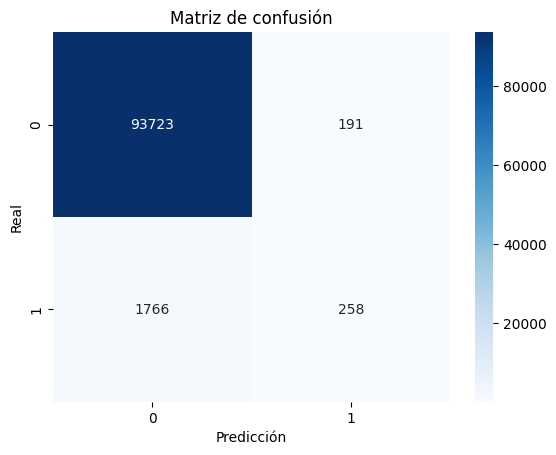

In [76]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

## Modelo con `class_weight` = "balanced"

In [106]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=10000,
        n_jobs=-1,
        class_weight="balanced",
    ))
])

In [107]:
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [108]:
y_pred = pipeline.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.85      0.92     93914
           1       0.11      0.83      0.19      2024

    accuracy                           0.85     95938
   macro avg       0.55      0.84      0.56     95938
weighted avg       0.98      0.85      0.90     95938



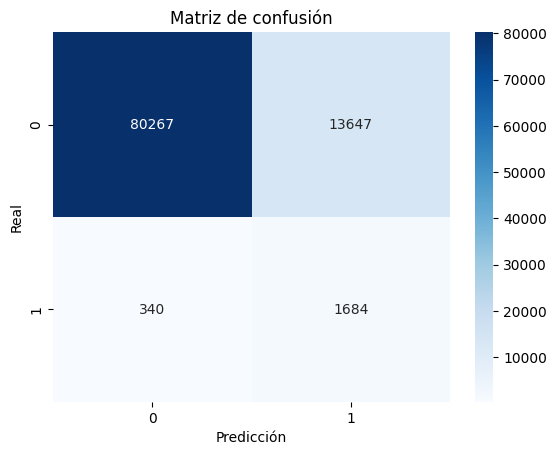

In [109]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

In [110]:
mask_false_negative = (y_test == 1) & (y_pred == 0)
false_negatives = X_test.loc[mask_false_negative]

In [111]:
false_negative_rows = df.loc[false_negatives.index, num_cols_inicial + obj_cols]
false_negative_rows

,age,preauth_amt,claim_amount,critical_organ_failure,hemodynamic_instability,mechanical_life_support,severe_infection,hemorrhage_or_stroke,severe_systemic_disease,amounts_diff,amounts_diff_ratio,preauth-surgery_days,sex,category_name,hosp_type,age_group_new,category_risk_level
7365,0,35000,35000,0,1,0,0,0,0,0,0.000000,-3,male,pediatrics,government,0,low
5865,55,115846,110000,0,0,0,0,0,0,5846,0.050464,1,male,cardiac and cardiothoracic surgery,corporate,51-65,low
464875,71,7000,7000,1,0,0,0,0,0,0,0.000000,-3,female,cardiology,corporate,66+,high
365189,66,26520,20000,0,0,0,0,0,0,6520,0.245852,2,male,radiation oncology,corporate,66+,low
242020,3,86700,86700,0,0,0,0,0,0,0,0.000000,1,male,cardiac and cardiothoracic surgery,corporate,1-18,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219020,51,12500,11250,0,0,0,0,0,0,1250,0.100000,2,male,nephrology,corporate,51-65,low
39441,51,60000,55000,0,0,0,0,0,0,5000,0.083333,9,male,cardiac and cardiothoracic surgery,corporate,51-65,low
303141,32,48000,48000,0,0,1,0,0,0,0,0.000000,-2,male,poly trauma,corporate,19-35,low
168574,43,3060,3060,0,0,1,0,0,0,0,0.000000,-3,male,medical oncology,corporate,36-50,low


In [112]:
coefs_df = pd.DataFrame({
    "Variable": covariables,
    "Coeficiente": pipeline.named_steps["clf"].coef_[0]
})

coefs_df = coefs_df.sort_values(by="Coeficiente", ascending=False)
coefs_df

,Variable,Coeficiente
10,amounts_diff_ratio,1.020638
47,category_risk_level_low,0.716471
0,age,0.572408
5,mechanical_life_support,0.394245
26,category_name_nephrology,0.340632
28,category_name_neurosurgery,0.330421
48,category_risk_level_high,0.327570
2,claim_amount,0.303810
3,critical_organ_failure,0.266213
27,category_name_neurology,0.207686


In [113]:
from sklearn.metrics import roc_curve, auc
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
roc_auc

0.9164564801149753

## Modelo con stepwise_selection

In [ ]:
def stepwise_selection_logistic(X, y, initial_list=None, threshold_in=0.1, threshold_out=0.1, verbose=True):
    if initial_list is None:
        included = []
    else:
        included = list(initial_list)

    while True:
        changed = False

        excluded = [col for col in X.columns if col not in included]
        new_pvalues = pd.Series(index=excluded, dtype=float)

        for col in excluded:
            model = sm.Logit(y, sm.add_constant(X[included + [col]])).fit(disp=0)
            new_pvalues[col] = model.pvalues[col]

        if not new_pvalues.empty:
            best_pval = new_pvalues.min()
            if best_pval < threshold_in:
                best_feature = new_pvalues.idxmin()
                included.append(best_feature)
                changed = True
                if verbose:
                    print(f"Añadido {best_feature:30} p-value={best_pval:.6f}")

        if included:
            model = sm.Logit(y, sm.add_constant(X[included])).fit(disp=0, maxiter=1000)
            pvalues = model.pvalues.iloc[1:]
            worst_pval = pvalues.max()
            if worst_pval > threshold_out:
                worst_feature = pvalues.idxmax()
                included.remove(worst_feature)
                changed = True
                if verbose:
                    print(f"Eliminado {worst_feature:28} p-value={worst_pval:.6f}")

        if not changed:
            break

    return included

In [ ]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("\nPaso forward/backward:")
best_features_logit = stepwise_selection_logistic(X_scaled, y, initial_list=[])
print("\nVariables seleccionadas por stepwise:")
print(best_features_logit)

final_model_logit = sm.Logit(y, sm.add_constant(X_scaled[best_features_logit])).fit(maxiter=1000)
print("\nModelo final con variables seleccionadas:")
print(final_model_logit.summary())


Paso forward/backward:


c:\Github\NTR-Arogyaseva-analysis\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Github\NTR-Arogyaseva-analysis\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Github\NTR-Arogyaseva-analysis\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Github\NTR-Arogyaseva-analysis\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


KeyboardInterrupt: 

## Modelo de recién nacidos

In [ ]:
X_rn = X[X["age"]==0]
y_rn = y[X_rn.index]

print(X_rn.shape)
print(y_rn.shape)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_rn, y_rn, test_size=0.2, random_state=42, stratify=y_rn)

In [ ]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=10000,
        n_jobs=-1,
        class_weight="balanced",
    ))
])

In [ ]:
pipeline.fit(X_train, y_train)

In [ ]:
y_pred = pipeline.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

## Modelo completo sin categorías de bajo riesgo
Se excluyen todos los datos vinculados a valores de category_name con riesgo de mortalidad nulo.

In [ ]:
bajo_riesgo = [
    "category_name_gynaecology and obstetrics surgery",
	"category_name_orthopedic surgery and procedures",
    "category_name_cochlear implant surgery",
    "category_name_ent surgery",
    "category_name_dermatology",
    "category_name_ophthalmology surgery",
    "category_name_prostheses"
]

In [ ]:
X_ar = X.copy().drop(columns=bajo_riesgo)
y_ar = y[X_ar.index]

category_cols = [col for col in X_ar.columns if col.startswith("category_name")]

mask = (X_ar[category_cols] != 0).any(axis=1)

X_ar = X_ar.loc[mask].copy()
y_ar = y_ar.loc[mask].copy()

print(X_ar.shape)
print(y_ar.shape)

(433140, 74)
(433140,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_ar, y_ar, test_size=0.2, random_state=42, stratify=y_ar)

In [ ]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=10000,
        n_jobs=-1,
        class_weight="balanced",
    ))
])

In [ ]:
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [ ]:
y_pred = pipeline.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.79      0.88     84606
           1       0.09      0.84      0.15      2022

    accuracy                           0.79     86628
   macro avg       0.54      0.81      0.52     86628
weighted avg       0.97      0.79      0.86     86628



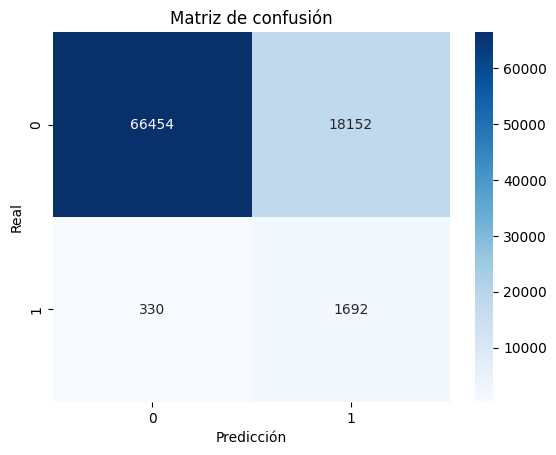

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

## Modelo con librería pingouin

In [ ]:
from pingouin import logistic_regression

results = logistic_regression(X, y, max_iter=1000)
results

In [ ]:
results["significativa"] = (results["pval"]<0.05)
results.sort_values("pval")